<a href="https://colab.research.google.com/github/iNx998/testrepo/blob/main/stc_TV_T2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# STC Jawwy

In [1]:
"""
Here we install libraries that are not installed by default
Example:  pyslsb
Feel free to add any library you are planning to use.
"""
!pip install pyxlsb

In [2]:
# Import the required libraries
"""
Please feel free to import any required libraries as per your needs
"""
import pandas as pd     # provides high-performance, easy to use structures and data analysis tools
import pyxlsb           # Excel extention to read xlsb files (the input file)
import numpy as np      # provides fast mathematical computation on arrays and matrices

In [10]:
from google.colab import files

print("Please upload the 'stc TV Data Set_T2.xlsb' file.")
uploaded = files.upload()

for fn in uploaded.keys():
    print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Please upload the 'stc TV Data Set_T2.xlsb' file.


Saving stc TV Data Set_T2.xlsx to stc TV Data Set_T2 (1).xlsx
User uploaded file "stc TV Data Set_T2 (1).xlsx" with length 10214 bytes


# Jawwy dataset
The dataset includes total watching hours for customers per day.

You are required to work on predecting the forecast for the watching hours.

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [24]:
dataframe = pd.read_excel("stc TV Data Set_T2 (1).xlsx",index_col=0)
# Please make a copy of dataset if you are going to work directly and makze changes on the dataset
# you can use   df=dataframe.copy()

In [12]:
# check the data shape
dataframe.shape

(86, 2)

In [14]:
# display the first 5 rows
dataframe.head()

,date_,Total_watch_time_in_houres
0,2018-01-01,1123.551944
1,2018-01-02,1000.129722
2,2018-01-03,881.924444
3,2018-01-04,782.669444
4,2018-01-05,1051.939444


In [16]:
# display the dataset after applying data types
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 86 entries, 0 to 85
Data columns (total 2 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   date_                       86 non-null     datetime64[ns]
 1   Total_watch_time_in_houres  86 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.0 KB


In [17]:
# describe the numeric values in the dataset
dataframe.describe()

,date_,Total_watch_time_in_houres
count,86,86.000000
mean,2018-02-28 17:01:23.720930304,780.817926
min,2018-01-01 00:00:00,562.124722
25%,2018-01-30 06:00:00,707.709653
50%,2018-02-28 12:00:00,763.181389
75%,2018-03-29 18:00:00,840.985278
max,2018-04-30 00:00:00,1123.551944
std,NaN,122.992002


In [18]:
# check if any column has null value in the dataset
dataframe.isnull().any()

,0
date_,False
Total_watch_time_in_houres,False


In [19]:
# we import Visualization libraries
# you can ignore and use any other graphing libraries
import matplotlib.pyplot as plt # a comprehensive library for creating static, animated, and interactive visualizations
import plotly #a graphing library makes interactive, publication-quality graphs. Examples of how to make line plots, scatter plots, area charts, bar charts, error bars, box plots, histograms, heatmaps, subplots, multiple-axes, polar charts, and bubble charts.
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [20]:
# Setting the date as index
dataframe.set_index('date_', inplace=True)

In [21]:
# Display the dataframe after setting the date as index
dataframe.head()

,Total_watch_time_in_houres
date_,
2018-01-01,1123.551944
2018-01-02,1000.129722
2018-01-03,881.924444
2018-01-04,782.669444
2018-01-05,1051.939444


In [22]:
# show the dataframe
fig = px.line(dataframe,  y="Total_watch_time_in_houres")
fig.show()

            ds        yhat  yhat_lower  yhat_upper
120 2018-05-01  641.741126  519.669433  758.001271
121 2018-05-02  622.789898  497.451868  750.847227
122 2018-05-03  624.439631  497.438935  741.010105
123 2018-05-04  650.433177  526.988051  768.495731
124 2018-05-05  488.148887  364.434583  603.961641
125 2018-05-06  485.871179  365.504867  598.506748
126 2018-05-07  638.709543  528.677359  758.843294
127 2018-05-08  625.797551  506.812064  747.224355
128 2018-05-09  606.846322  484.416163  727.713018
129 2018-05-10  608.496055  493.869258  720.856132
130 2018-05-11  634.489602  523.728540  753.667459
131 2018-05-12  472.205311  345.458439  596.211378
132 2018-05-13  469.927603  355.660364  592.454340
133 2018-05-14  622.765967  510.272645  731.673123
134 2018-05-15  609.853975  490.532890  735.320756
135 2018-05-16  590.902746  470.824072  709.706813
136 2018-05-17  592.552479  483.188704  711.333151
137 2018-05-18  618.546026  507.451159  737.531984
138 2018-05-19  456.261736  332

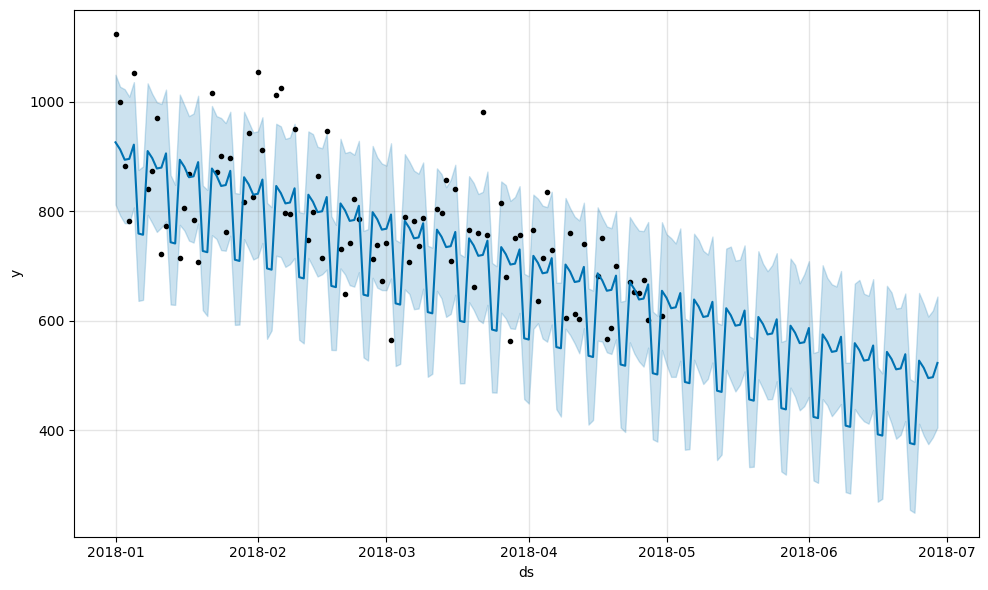

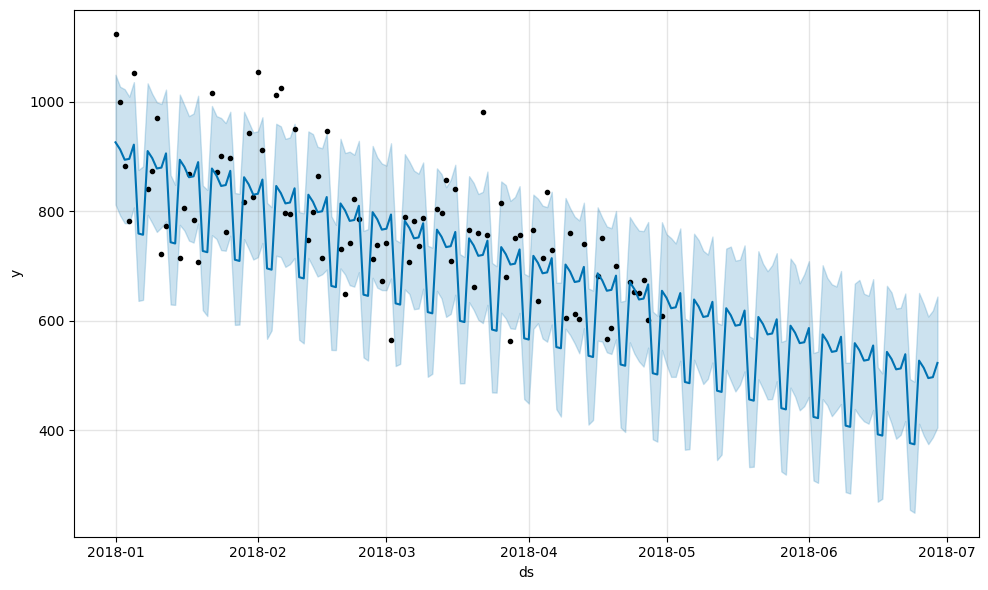

In [25]:

from prophet import Prophet

# =========================
# 1. Prepare Data
# =========================
# Reset the index to make 'date_' a column again
dataframe_reset = dataframe.reset_index()
dataframe_model = dataframe_reset[['date_', 'Total_watch_time_in_houres']].copy()

# Rename columns for Prophet
dataframe_model.columns = ['ds', 'y']

# Convert to datetime
dataframe_model['ds'] = pd.to_datetime(dataframe_model['ds'])

# Sort values (important)
dataframe_model = dataframe_model.sort_values('ds')

# Ensure daily frequency (fills missing dates if any)
dataframe_model = dataframe_model.set_index('ds').asfreq('D').reset_index()

# =========================
# 2. Build Model
# =========================
model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False
)

# Fit model
model.fit(dataframe_model)

# =========================
# 3. Forecast (Next 60 Days)
# =========================
future = model.make_future_dataframe(periods=60)

forecast = model.predict(future)

# =========================
# 4. Results
# =========================
forecast_result = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(60)

print(forecast_result)

# =========================
# 5. Plot Forecast
# =========================
model.plot(forecast)

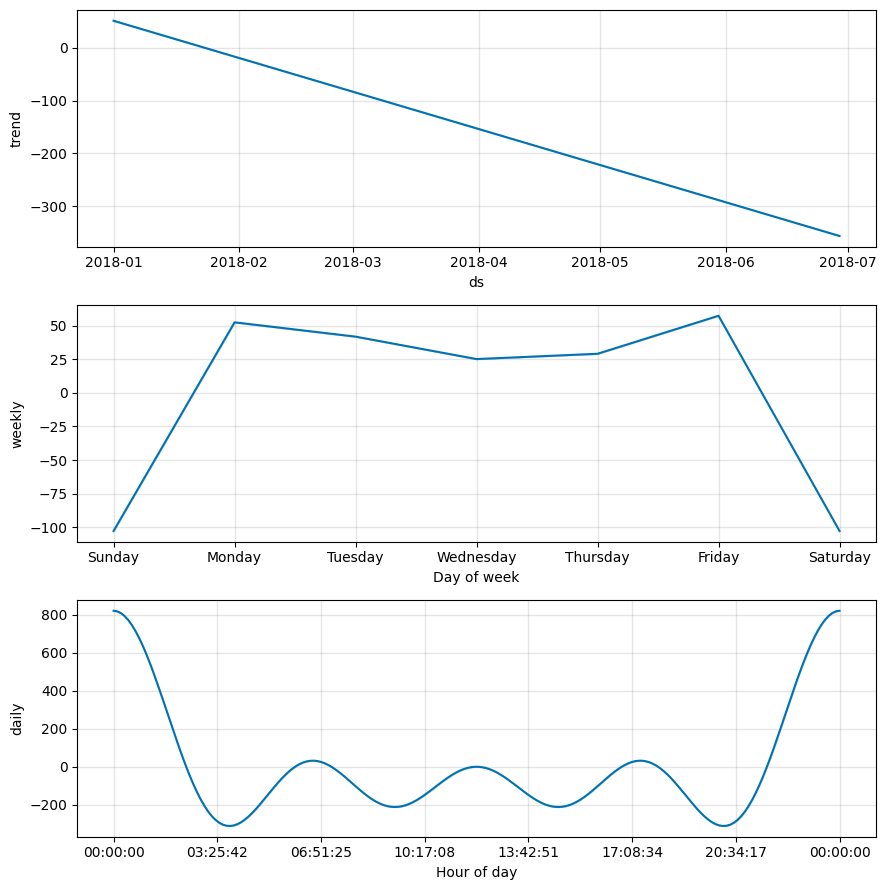

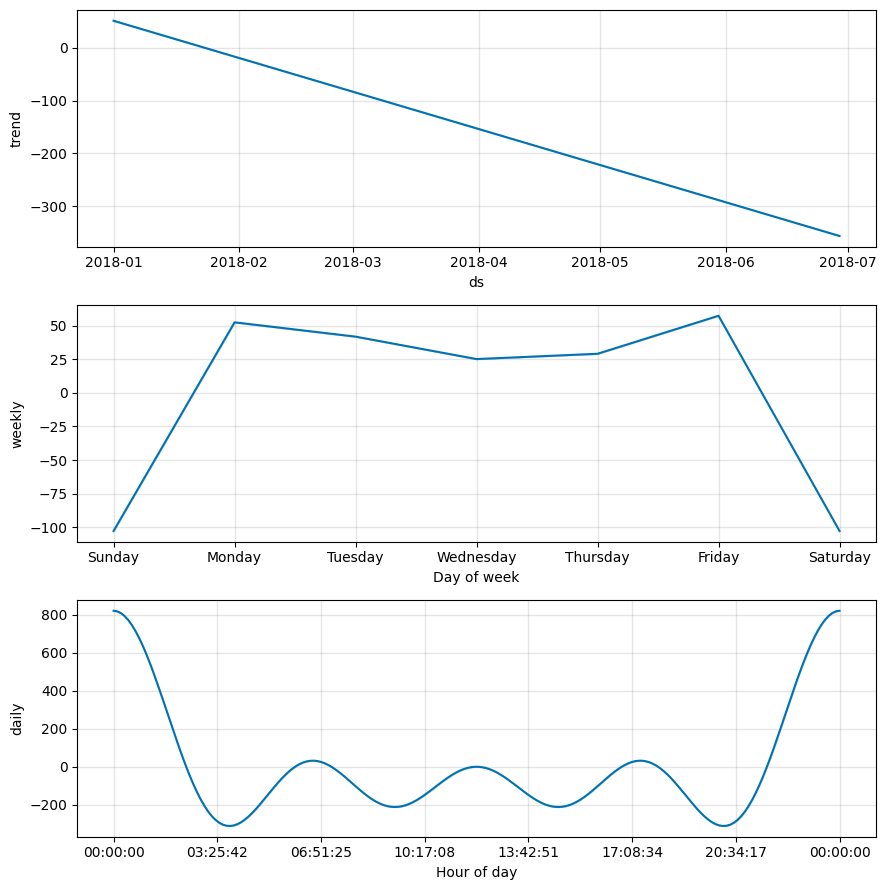

In [26]:
# Plot the individual forecast components
model.plot_components(forecast)

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Merge actuals with forecast to get historical predictions
performance_df = pd.merge(dataframe_model, forecast[['ds', 'yhat']], on='ds', how='inner')

# Drop rows with NaN values from the 'y' column before calculating metrics
performance_df.dropna(subset=['y'], inplace=True)

# Calculate MAE
mae = mean_absolute_error(performance_df['y'], performance_df['yhat'])
print(f'Mean Absolute Error (MAE): {mae:.2f}')

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(performance_df['y'], performance_df['yhat']))
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

Mean Absolute Error (MAE): 72.07
Root Mean Squared Error (RMSE): 92.54


In [30]:
forecast.to_csv('forecast_data.csv', index=False)
print('Forecast data saved to forecast_data.csv')

Forecast data saved to forecast_data.csv
